In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
data_dir = './data/Train'  # Update this path!
batch_size = 1024
epochs = 15
num_classes = 43

# Automatically use GPU if available on Windows
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

In [4]:
# Custom wrapper to apply different transforms to Train/Val splits
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

print("Loading dataset...")
# Load raw dataset without transforms first, then split
base_dataset = datasets.ImageFolder(root="./data/Train")

old_to_new = {old_idx: int(cls_name) for cls_name, old_idx in base_dataset.class_to_idx.items()}
base_dataset.samples = [(path, old_to_new[old_idx]) for path, old_idx in base_dataset.samples]
base_dataset.targets = [old_to_new[old_idx] for old_idx in base_dataset.targets]

train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(123))

Loading dataset...


In [5]:
# Apply specific transforms
train_dataset = TransformedSubset(train_subset, transform=train_transforms)
val_dataset = TransformedSubset(val_subset, transform=val_transforms)


train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [6]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # If input is 32x32:
        # After Pool 1: 16x16
        # After Pool 2: 8x8
        # After Pool 3: 4x4
        # Flattened: 256 channels * 4 * 4 = 4096
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = TrafficSignCNN(num_classes=num_classes).to(device)

In [7]:
# nn.CrossEntropyLoss handles raw logits automatically (equivalent to from_logits=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
history = {'train_acc': [], 'val_acc': []}

print("Starting training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()           # Clear old gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()                 # Backward pass (gradients)
        optimizer.step()                # Update weights
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_accuracy = correct_train / total_train
    history['train_acc'].append(train_accuracy)
    
    # --- VALIDATION PHASE ---
    model.eval()
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_accuracy = correct_val / total_val
    history['val_acc'].append(val_accuracy)
    
    print(f"Train Acc: {train_accuracy*100:.2f}% | Val Acc: {val_accuracy*100:.2f}%")

Starting training...


Epoch 1/15: 100%|██████████| 31/31 [00:12<00:00,  2.56it/s]


Train Acc: 61.66% | Val Acc: 33.82%


Epoch 2/15: 100%|██████████| 31/31 [00:11<00:00,  2.58it/s]


Train Acc: 95.51% | Val Acc: 96.67%


...

Train Acc: 99.93% | Val Acc: 99.89%


Epoch 14/15: 100%|██████████| 31/31 [00:12<00:00,  2.46it/s]


Train Acc: 99.91% | Val Acc: 99.83%


Epoch 15/15: 100%|██████████| 31/31 [00:12<00:00,  2.51it/s]


Train Acc: 99.95% | Val Acc: 99.81%


In [9]:
torch.save(model.state_dict(), 'traffic_sign_classifier.pth')
print("Model weights saved successfully as 'traffic_sign_classifier.pth'!")

Model weights saved successfully as 'traffic_sign_classifier.pth'!


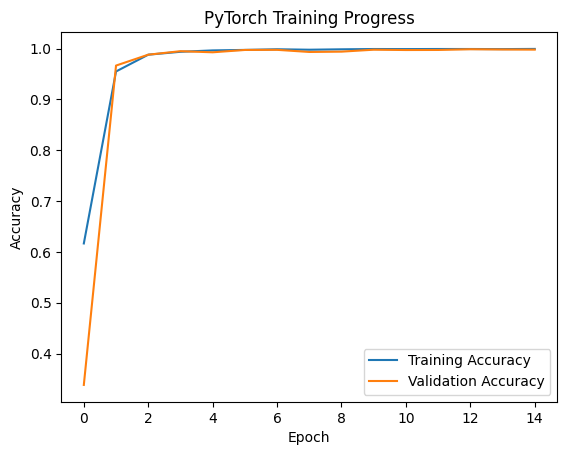

In [10]:
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('PyTorch Training Progress')
plt.show()